In [1]:
# Run garbage collection
import gc
gc.collect()

0

In [2]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import logging
import wfdb
import ast
import torch
import seaborn as sns
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_score, recall_score, confusion_matrix
from tabulate import tabulate
import os
from collections import Counter

In [3]:
def load_data(df, sampling_rate, path):
    if sampling_rate == 100:
        data = [wfdb.rdsamp(path+f) for f in df.filename_lr]
    else:
        data = [wfdb.rdsamp(path+f) for f in df.filename_hr]
    metadata = data
    data = np.array([signal for signal, meta in data])
    return data, metadata

path = '../dataset/ptb_xl/'
sampling_rate=100

ECG_df = pd.read_csv(os.path.join(path+'ptbxl_database.csv'), index_col='ecg_id')
ECG_df.scp_codes = ECG_df.scp_codes.apply(lambda x: ast.literal_eval(x))
ECG_df.patient_id = ECG_df.patient_id.astype(int)
ECG_df.nurse = ECG_df.nurse.astype('Int64')
ECG_df.site = ECG_df.site.astype('Int64')
ECG_df.validated_by = ECG_df.validated_by.astype('Int64')

SCP_df = pd.read_csv(os.path.join(path, 'scp_statements.csv'), index_col=0)
SCP_df = SCP_df[SCP_df.diagnostic == 1]

ECG_df.head()

,patient_id,age,sex,height,weight,nurse,site,device,recording_date,report,...,validated_by_human,baseline_drift,static_noise,burst_noise,electrodes_problems,extra_beats,pacemaker,strat_fold,filename_lr,filename_hr
ecg_id,,,,,,,,,,,,,,,,,,,,,
1,15709,56.0,1,NaN,63.0,2,0,CS-12 E,1984-11-09 09:17:34,sinusrhythmus periphere niederspannung,...,True,NaN,", I-V1,",NaN,NaN,NaN,NaN,3,records100/00000/00001_lr,records500/00000/00001_hr
2,13243,19.0,0,NaN,70.0,2,0,CS-12 E,1984-11-14 12:55:37,sinusbradykardie sonst normales ekg,...,True,NaN,NaN,NaN,NaN,NaN,NaN,2,records100/00000/00002_lr,records500/00000/00002_hr
3,20372,37.0,1,NaN,69.0,2,0,CS-12 E,1984-11-15 12:49:10,sinusrhythmus normales ekg,...,True,NaN,NaN,NaN,NaN,NaN,NaN,5,records100/00000/00003_lr,records500/00000/00003_hr
4,17014,24.0,0,NaN,82.0,2,0,CS-12 E,1984-11-15 13:44:57,sinusrhythmus normales ekg,...,True,", II,III,AVF",NaN,NaN,NaN,NaN,NaN,3,records100/00000/00004_lr,records500/00000/00004_hr
5,17448,19.0,1,NaN,70.0,2,0,CS-12 E,1984-11-17 10:43:15,sinusrhythmus normales ekg,...,True,", III,AVR,AVF",NaN,NaN,NaN,NaN,NaN,4,records100/00000/00005_lr,records500/00000/00005_hr


In [4]:
def diagnostic_class(scp):
    res = set()
    for k in scp.keys():
        if k in SCP_df.index:
            res.add(SCP_df.loc[k].diagnostic_class)
    return list(res)
                    
ECG_df['scp_classes'] = ECG_df.scp_codes.apply(diagnostic_class)

In [5]:
def load_raw_data(df, sampling_rate, path):
    if sampling_rate == 100:
        data = [wfdb.rdsamp(os.path.join(path, f)) for f in df.filename_lr]
    else:
        data = [wfdb.rdsamp(os.path.join(path, f)) for f in df.filename_hr]
    data = np.array([signal for signal, meta in data])
    return data

sampling_rate = 100

ECG_data = load_raw_data(ECG_df, sampling_rate, path)

ECG_data.shape

(21799, 1000, 12)

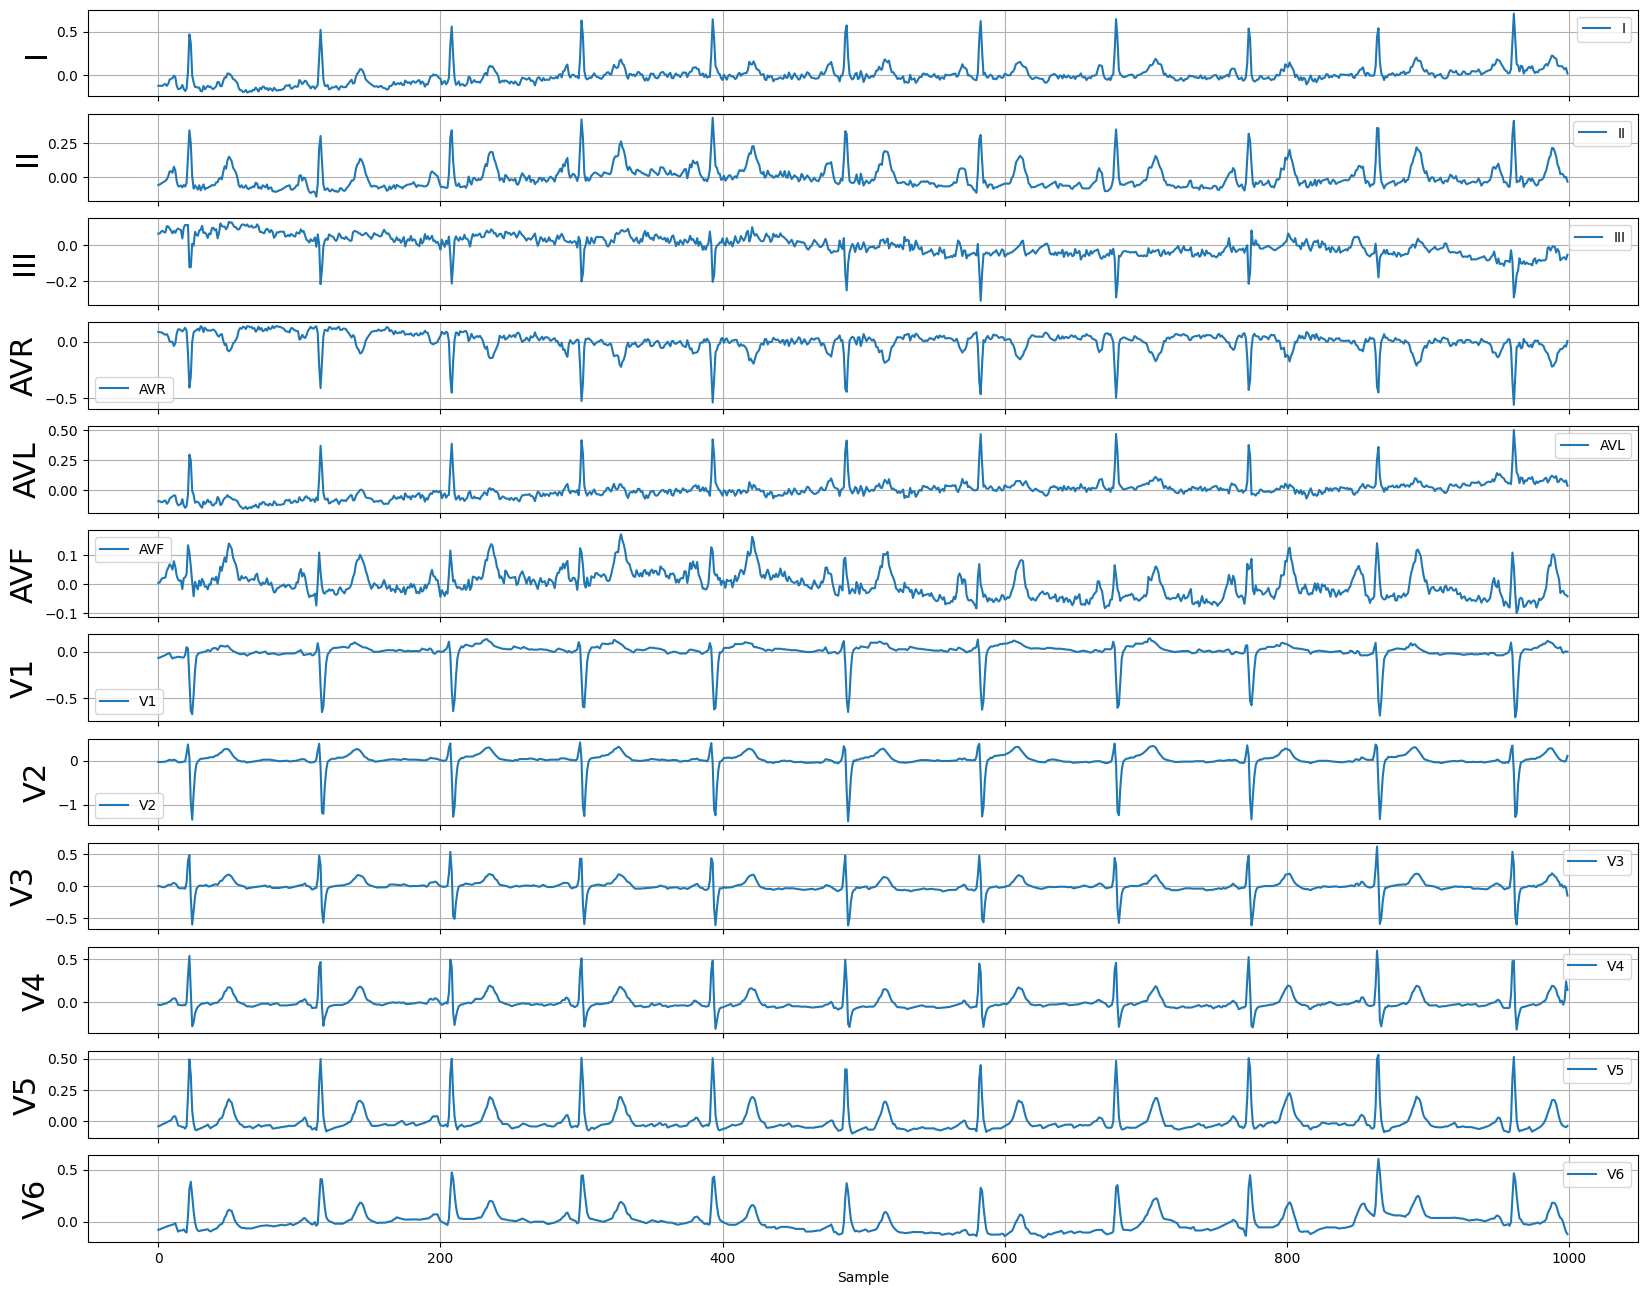

In [7]:
sample = ECG_data[0]
lead_names = ['I', 'II', 'III', 'AVR', 'AVL', 'AVF', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6']
bar, axes = plt.subplots(sample.shape[1], 1, figsize=(20, 16), sharex=True)

for i in range(sample.shape[1]):
    sns.lineplot(x=np.arange(sample.shape[0]), y=sample[:, i], ax=axes[i], label=lead_names[i])
    axes[i].set_ylabel(lead_names[i], fontsize=22)
    axes[i].grid(True)

axes[-1].set_xlabel('Sample')
plt.show()

In [8]:
ECG_df[[col for col in ECG_df.columns if col not in ('scp_codes', 'scp_classes')]].nunique(dropna=True)


patient_id                      18869
age                                89
sex                                 2
height                             77
weight                            127
nurse                              12
site                               51
device                             11
recording_date                  21795
report                           9887
heart_axis                          8
infarction_stadium1                 6
infarction_stadium2                 3
validated_by                       12
second_opinion                      2
initial_autogenerated_report        2
validated_by_human                  2
baseline_drift                    317
static_noise                      124
burst_noise                       103
electrodes_problems                14
extra_beats                       128
pacemaker                           4
strat_fold                         10
filename_lr                     21799
filename_hr                     21799
dtype: int64

In [9]:
X = pd.DataFrame(index=ECG_df.index)

X['age'] = ECG_df.age.fillna(0)
X['sex'] = ECG_df.sex.astype(float).fillna(0)
X['height'] = ECG_df.height
X.loc[X.height < 50, 'height'] = np.nan
X['height'] = X['height'].fillna(0)
X['weight'] = ECG_df.weight.fillna(0)

X['infarction_stadium1'] = ECG_df.infarction_stadium1.replace({
    'unknown': 0,
    'Stadium I': 1,
    'Stadium I-II': 2,
    'Stadium II': 3,
    'Stadium II-III': 4,
    'Stadium III': 5
}).infer_objects(copy=False)
X['infarction_stadium1'] = X['infarction_stadium1'].fillna(0)

X['infarction_stadium2'] = ECG_df.infarction_stadium2.replace({
    'unknown': 0,
    'Stadium I': 1,
    'Stadium II': 2,
    'Stadium III': 3
}).infer_objects(copy=False)
X['infarction_stadium2'] = X['infarction_stadium2'].fillna(0)

X['pacemaker'] = (ECG_df.pacemaker == 'ja, pacemaker').astype(float)

#X

/tmp/ipykernel_22942/2071435787.py:10: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  X['infarction_stadium1'] = ECG_df.infarction_stadium1.replace({
/tmp/ipykernel_22942/2071435787.py:20: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  X['infarction_stadium2'] = ECG_df.infarction_stadium2.replace({


In [10]:
Z = pd.DataFrame(0, index=ECG_df.index, columns=['NORM', 'MI', 'STTC', 'CD', 'HYP'], dtype='int')
for i in Z.index:
    for k in ECG_df.loc[i].scp_classes:
        Z.loc[i, k] = 1

In [11]:
# Use .loc to get the integer positions, then use those to index ECG_data
train_idx = np.where(ECG_df.strat_fold <= 8)[0]
valid_idx = np.where(ECG_df.strat_fold == 9)[0]
test_idx  = np.where(ECG_df.strat_fold == 10)[0]

X_train, Y_train, Z_train = X.iloc[train_idx],  ECG_data[train_idx],  Z.iloc[train_idx]
X_valid, Y_valid, Z_valid = X.iloc[valid_idx],  ECG_data[valid_idx],  Z.iloc[valid_idx]
X_test,  Y_test,  Z_test  = X.iloc[test_idx],   ECG_data[test_idx],   Z.iloc[test_idx]

print(X_train.shape, Y_train.shape, Z_train.shape)
print(X_valid.shape, Y_valid.shape, Z_valid.shape)
print(X_test.shape,  Y_test.shape,  Z_test.shape)

(17418, 7) (17418, 1000, 12) (17418, 5)
(2183, 7) (2183, 1000, 12) (2183, 5)
(2198, 7) (2198, 1000, 12) (2198, 5)


In [ ]:
# # Save X, Z splits to 
# path_save = 'data_source'
# X_train.to_csv(path_save+"X_train.csv")
# X_valid.to_csv(path_save+"X_valid.csv")
# X_test.to_csv(path_save+"X_test.csv")

# Z_train.to_csv(path_save+"Z_train.csv")
# Z_valid.to_csv(path_save+"Z_valid.csv")
# Z_test.to_csv(path_save+"Z_test.csv")

# # Save Y (ECG signals) as numpy arrays (since they are not DataFrames)
# np.save(path_save+"Y_train.npy", Y_train)
# np.save(path_save+"Y_valid.npy", Y_valid)
# np.save(path_save+"Y_test.npy", Y_test)

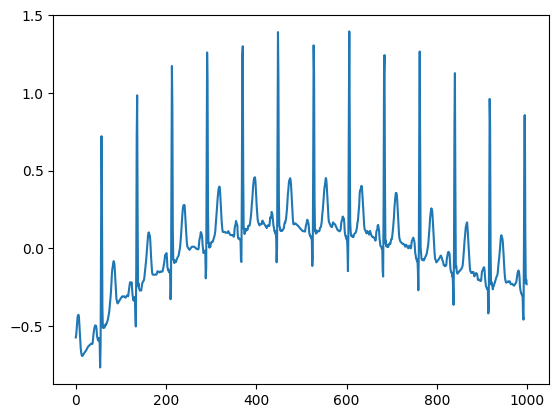

In [11]:
ecg_ = Y_train[56, :, 1]
plt.plot(ecg_)

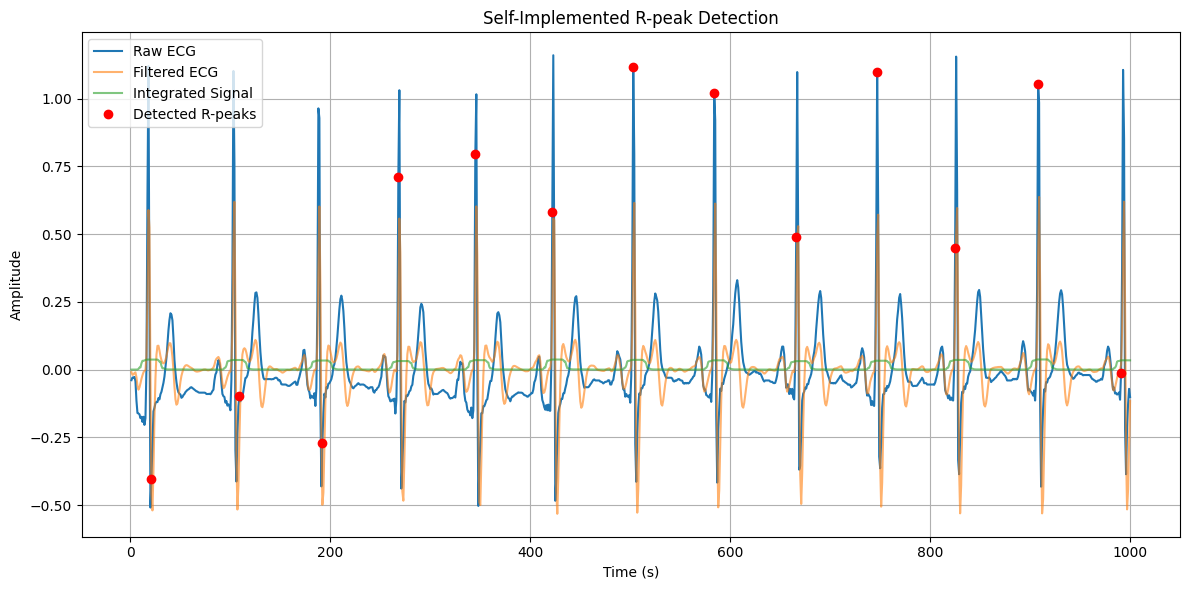

In [ ]:
# import numpy as np
# import matplotlib.pyplot as plt
# from scipy.signal import butter, lfilter, find_peaks

# ecg_ = Y_train[23, :, 1]
# # --- Bandpass Filter (5–15 Hz) ---
# def bandpass_filter(signal, fs, lowcut=5.0, highcut=15.0, order=1):
#     nyq = 0.5 * fs
#     low = lowcut / nyq
#     high = highcut / nyq
#     b, a = butter(order, [low, high], btype='band')
#     return lfilter(b, a, signal)

# # --- Main Self-Implemented R-Peak Detection ---
# def detect_r_peaks(signal, fs):
#     # 1. Bandpass filter
#     filtered = bandpass_filter(signal, fs)

#     # 2. Derivative
#     diff = np.diff(filtered, prepend=filtered[0])

#     # 3. Squaring
#     squared = diff ** 2

#     # 4. Moving average window integration
#     window_size = int(0.20 * fs)  # 150ms
#     mwa = np.convolve(squared, np.ones(window_size)/window_size, mode='same')

#     # 5. Peak detection with threshold
#     threshold = np.mean(mwa) * 1.5
#     peaks, _ = find_peaks(mwa, height=threshold, distance=int(0.3 * fs))

#     return peaks, mwa, filtered

# # --- Run it ---
# fs = 100
# t = np.arange(1, len(ecg_) + 1)  # t ranges from 1 to 1000

# peaks, mwa, filtered = detect_r_peaks(ecg_, fs)

# # --- Plot Results ---
# plt.figure(figsize=(12, 6))
# plt.plot(t, ecg_, label='Raw ECG')
# plt.plot(t, filtered, label='Filtered ECG', alpha=0.6)
# plt.plot(t, mwa, label='Integrated Signal', alpha=0.6)
# plt.plot(t[peaks], ecg_[peaks], 'ro', label='Detected R-peaks')
# plt.legend()
# plt.title("Self-Implemented R-peak Detection")
# plt.xlabel("Time (s)")
# plt.ylabel("Amplitude")
# plt.grid(True)
# plt.tight_layout()
# plt.show()

In [12]:
def detect_r_peaks(ecg_, fs):
    """
    Simple R-peak detector using diff, squaring, moving window integration, and adaptive thresholding.
    Returns: indices of detected R-peaks.
    """
    def simple_diff(signal):
        diff = []
        for i in range(1, len(signal)):
            diff.append(signal[i] - signal[i-1])
        return np.array(diff)

    diff = simple_diff(ecg_)
    diff = np.append(diff, 0)  # Append zero to match original length

    # Step 2: Squaring
    squared = diff ** 2

    # Step 3: Moving window integration
    window_size = int(0.150 * fs)  # 150 ms window
    integrated = np.convolve(squared, np.ones(window_size) / window_size, mode='same')

    # Step 4: Simple adaptive thresholding and refractory period
    threshold = np.mean(integrated) * 1.5
    refractory_period = int(0.10 * fs)  # 250 ms

    peaks = []
    last_peak = -refractory_period

    for i in range(1, len(integrated) - 1):
        if integrated[i] > threshold and integrated[i] > integrated[i - 1] and integrated[i] > integrated[i + 1]:
            if i - last_peak > refractory_period:
                # Local search in raw signal for actual peak in a small window
                window = ecg_[i-10:i+10]
                if len(window) == 20:
                    true_peak = i - 10 + np.argmax(window)
                    peaks.append(true_peak)
                    last_peak = true_peak
    return np.array(peaks), integrated, squared, diff

def plot_r_peak_detection(t, ecg_, peaks, squared, integrated):
    """
    Plot ECG signal, detected R-peaks, squared signal, and integrated signal.
    """
    plt.figure(figsize=(12, 4))
    plt.plot(t, ecg_, label="ECG Signal")
    plt.plot(t[peaks], ecg_[peaks], 'ro', label="Detected R-peaks")
    plt.plot(t, squared, label="Squared Signal", alpha=0.6)
    plt.plot(t, integrated, label="Integrated Signal", alpha=0.6)
    plt.title("Self-implemented R-Peak Detector")
    plt.xlabel("Time (s)")
    plt.ylabel("Amplitude")
    plt.legend()
    plt.grid()
    plt.show()

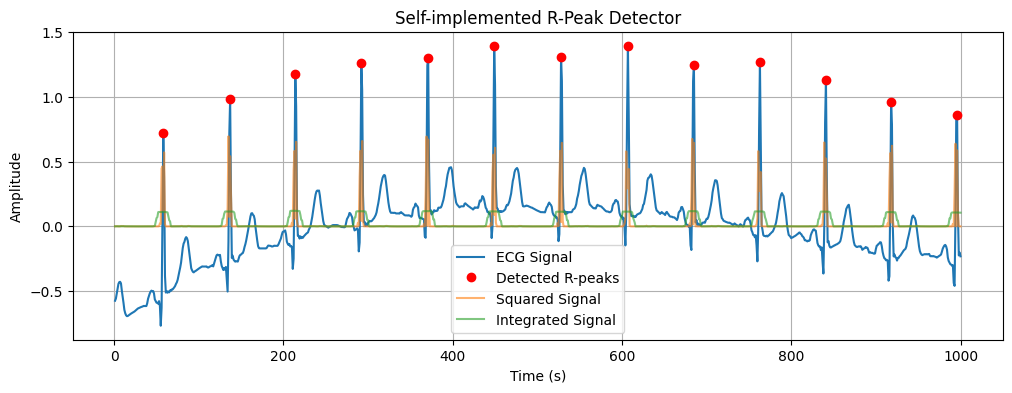

In [15]:
fs = 100
t = np.arange(1, len(ecg_) + 1)  # t ranges from 1 to 1000
r_peaks, integrated, squared, _ = detect_r_peaks(ecg_, fs)

plt.figure(figsize=(12, 4))
plt.plot(t, ecg_, label="ECG Signal")
plt.plot(t[r_peaks], ecg_[r_peaks], 'ro', label="Detected R-peaks")
plt.plot(t, squared, label="Squared Signal", alpha=0.6)
plt.plot(t, integrated, label="Integrated Signal", alpha=0.6)
plt.title("Self-implemented R-Peak Detector")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.legend()
plt.grid()
plt.show()

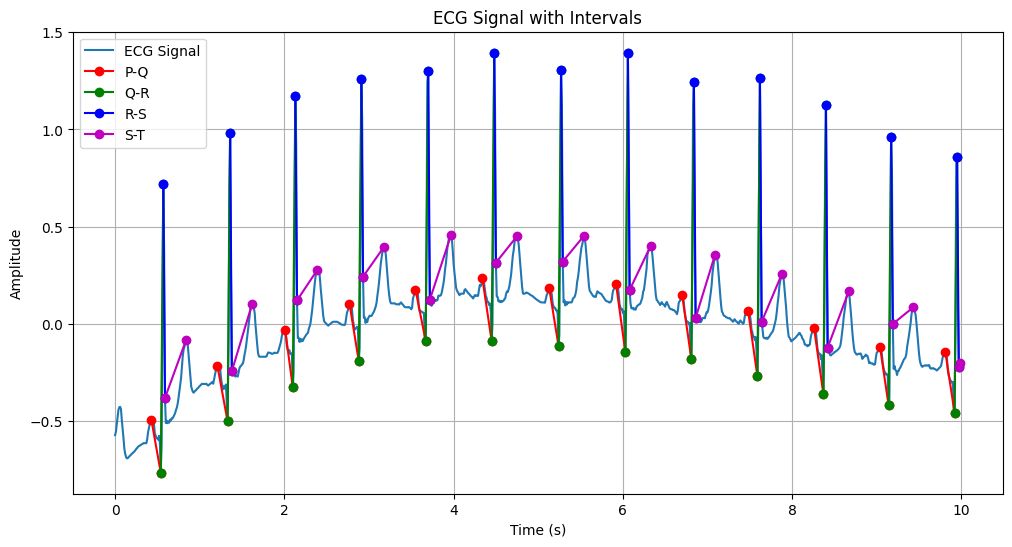

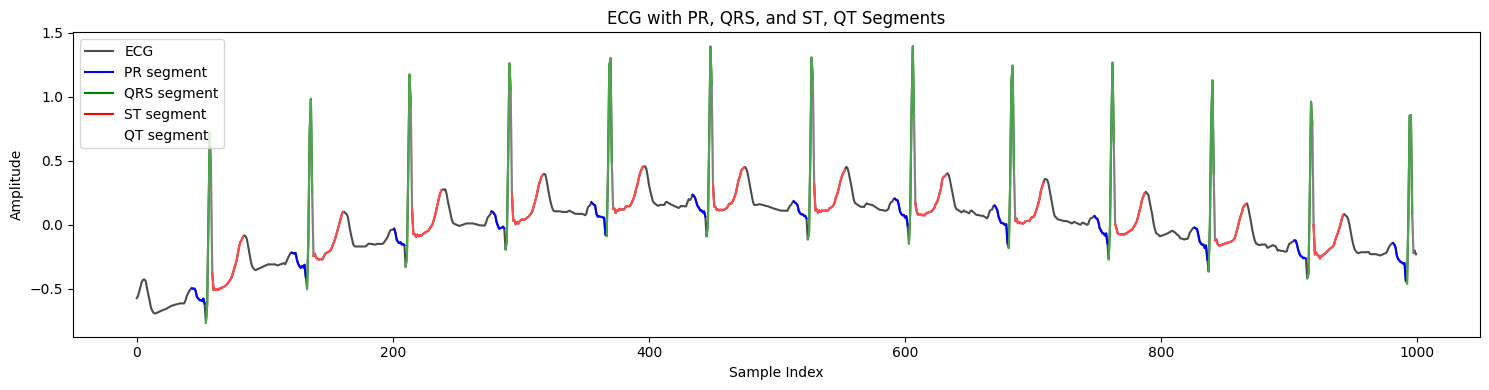

In [35]:
def find_wave_point(signal, start, end, find_min=True):
    segment = signal[start:end]
    if find_min:
        idx = segment.argmin()
    else:
        idx = segment.argmax()
    return start + idx

def compute_intervals(signal, r_peaks, fs):
    intervals = []
    for r in r_peaks:
        # Search window sizes in samples
        q_search_start = max(r - int(0.03 * fs), 0)
        q_search_end = r
        s_search_start = r
        s_search_end = min(r + int(0.03 * fs), len(signal))

        p_search_start = max(q_search_start - int(0.2 * fs), 0)
        p_search_end = q_search_start

        t_search_start = s_search_end
        t_search_end = min(s_search_end + int(0.3 * fs), len(signal))

        # Find Q, S, P, T waves
        q = find_wave_point(signal, q_search_start, q_search_end, find_min=True)
        s = find_wave_point(signal, s_search_start, s_search_end, find_min=True)
        p = find_wave_point(signal, p_search_start, p_search_end, find_min=False)
        t = find_wave_point(signal, t_search_start, t_search_end, find_min=False)
        
        intervals.append({
            'P': p,
            'Q': q,
            'R': r,
            'S': s,
            'T': t,
        })
    return intervals
def plot_intervals(signal, intervals, fs):
    plt.figure(figsize=(12, 6))
    t = np.arange(len(signal)) / fs
    plt.plot(t, signal, label='ECG Signal')

    for interval in intervals:
        r = interval['R'] / fs
        p = interval['P'] / fs
        q = interval['Q'] / fs
        s = interval['S'] / fs
        t_wave = interval['T'] / fs
        
        plt.plot([p, q], [signal[interval['P']], signal[interval['Q']]], 'ro-')
        plt.plot([q, r], [signal[interval['Q']], signal[interval['R']]], 'go-')
        plt.plot([r, s], [signal[interval['R']], signal[interval['S']]], 'bo-')
        plt.plot([s, t_wave], [signal[interval['S']], signal[interval['T']]], 'mo-')

    plt.title('ECG Signal with Intervals')
    plt.xlabel('Time (s)')
    plt.ylabel('Amplitude')
    plt.legend(['ECG Signal', 'P-Q', 'Q-R', 'R-S', 'S-T'])
    plt.grid()
    plt.show()

def extract_intervals_segments(signal, intervals, fs = 100):
    segments = []
    for i in intervals:
        p_idx = i['P']
        q_idx = i['Q']
        s_idx = i['S']
        t_idx = i['T']

        segments.append({
            'PR' : {'segment': signal[p_idx:q_idx] if p_idx < q_idx else np.array([]),
                    'start': p_idx,
                    'end': q_idx,
                    'duration': (s_idx - q_idx) / fs},

            'QRS': {'segment': signal[q_idx:s_idx] if q_idx < s_idx else np.array([]),
                    'start': q_idx,
                    'end': s_idx,
                    'duration': (s_idx - q_idx) / fs},

            'ST' : {'segment': signal[s_idx:t_idx] if s_idx < t_idx else np.array([]),
                    'start': s_idx,
                    'end': t_idx,
                    'duration': (s_idx - t_idx) / fs},
            
            'QT' : {'segment': signal[q_idx:t_idx] if q_idx < t_idx else np.array([]),
                    'start': q_idx,
                    'end': t_idx,
                    'duration': (q_idx - t_idx) / fs}
        })
    return segments


def plot_extracted_segments(signal, segments):
    plt.figure(figsize=(15, 4))
    plt.plot(signal, label='ECG', color='black', alpha=0.7)

    for i, seg in enumerate(segments):
        # Plot PR segment
        pr_seg = seg['PR']['segment']
        pr_start = seg['PR']['start']
        if len(pr_seg) > 0:
            plt.plot(range(pr_start, pr_start + len(pr_seg)), pr_seg, color='blue', label='PR segment' if i == 0 else "")

        # Plot QRS segment
        qrs_seg = seg['QRS']['segment']
        qrs_start = seg['QRS']['start']
        if len(qrs_seg) > 0:
            plt.plot(range(qrs_start, qrs_start + len(qrs_seg)), qrs_seg, color='green', label='QRS segment' if i == 0 else "")

        # Plot ST segment
        st_seg = seg['ST']['segment']
        st_start = seg['ST']['start']
        if len(st_seg) > 0:
            plt.plot(range(st_start, st_start + len(st_seg)), st_seg, color='red', label='ST segment' if i == 0 else "")
            
        qt_seg = seg['QT']['segment']
        qt_start = seg['QT']['start']
        if len(qt_seg) > 0:
            plt.plot(range(qt_start, qt_start + len(qt_seg)), qt_seg, color='w', alpha=0.3, label='QT segment' if i == 0 else "")

    plt.title("ECG with PR, QRS, and ST, QT Segments")
    plt.xlabel("Sample Index")
    plt.ylabel("Amplitude")
    plt.legend()
    plt.tight_layout()
    plt.show()

# Example usage:
# plot_extracted_segments(ecg_, segments, fs)
    
fs = 100
intervals = compute_intervals(ecg_, r_peaks, fs)
segments = extract_intervals_segments(ecg_, intervals)

plot_intervals(ecg_, intervals, fs)
plot_extracted_segments(ecg_, segments)

In [61]:
# Shannon entropy of a signal (quantize first)
def shannon_entropy(signal_segment, bins=50):
    """Compute Shannon entropy over a segment of the ECG signal."""
    if len(signal_segment) == 0:
        return 0.0
    hist, _ = np.histogram(signal_segment, bins=bins, density=True)
    hist = hist[hist > 0]  # Avoid log(0)
    return -np.sum(hist * np.log2(hist))

def approximate_entropy(U, m=2, r=0.2):
    def _maxdist(x_i, x_j):
        return np.max(np.abs(x_i - x_j))
    def _phi(m):
        N = len(U)
        x = np.array([U[i:i+m] for i in range(N - m + 1)])
        C = []
        for x_i in x:
            count = sum(_maxdist(x_i, x_j) <= r for x_j in x)
            C.append(count / (N - m + 1))
        return np.sum(np.log(C)) / (N - m + 1)
    if len(U) < m + 2:
        return np.nan
    return abs(_phi(m) - _phi(m + 1))

def sample_entropy(U, m=2, r=0.2, epsilon=1e-6):
    import numpy as np
    N = len(U)
    if N <= m + 1:
        return np.nan

    def _phi(U, m):
        x_m = np.array([U[i:i + m] for i in range(N - m)])
        count = 0
        for i in range(len(x_m)):
            for j in range(len(x_m)):
                if i != j and np.max(np.abs(x_m[i] - x_m[j])) <= r:
                    count += 1
        return count

    B = _phi(U, m)
    A = _phi(U, m + 1)

    # Add epsilon to avoid division by zero
    return -np.log((A + epsilon) / (B + epsilon))

def permutation_entropy(U, order=3, delay=1):
    n = len(U)
    if n < order * delay:
        return np.nan
    embedded = np.array([U[i:i + order * delay:delay] for i in range(n - (order - 1) * delay)])
    patterns = np.argsort(embedded, axis=1)
    _, counts = np.unique(patterns, axis=0, return_counts=True)
    probs = counts / counts.sum()
    return -np.sum(probs * np.log2(probs))

def multiscale_entropy(signal, m=2, r=0.2, scales=20):
    signal = np.asarray(signal)
    mse = []
    for scale in range(1, scales + 1):
        if len(signal) < scale:
            mse.append(np.nan)
            continue
        # Coarse-graining
        coarse = np.mean(signal[:len(signal) // scale * scale].reshape(-1, scale), axis=1)
        se = sample_entropy(coarse, m, r)
        mse.append(se)
    return np.array(mse)

def fuzzy_entropy(U, m=2, r=0.2, n=2):
    U = np.asarray(U)
    N = len(U)
    if N <= m + 1:
        return np.nan
    if r is None:
        r = 0.2 * np.std(U)
        
    def _embed(U, dim):
        return np.array([U[i:i+dim] for i in range(N - dim + 1)])

    def _fuzzy_count(X, r, n):
        count = 0.0
        N = len(X)
        for i in range(N):
            for j in range(N):
                if i != j:
                    dist = np.max(np.abs(X[i] - X[j]))
                    count += np.exp(-((dist / r) ** n))  # normalize distance by r
        return count / (N * (N - 1)) if N > 1 else np.nan

    Xm = _embed(U, m)
    Xm1 = _embed(U, m + 1)

    Cm = _fuzzy_count(Xm, r, n)
    Cm1 = _fuzzy_count(Xm1, r, n)

    if Cm1 == 0 or Cm == 0 or np.isnan(Cm1) or np.isnan(Cm):
        return np.nan

    return -np.log(Cm1 / Cm)

In [63]:
def compute_entropy_for_segments(ecg_, segments, m = 2, r_ratio = 0.2):
    """
    Compute ApEn, SampEn, and MultiscaleEn for the full ECG and for each PR, QRS, ST segment.
    Returns a dictionary with all entropy values.
    """
    entropy_results = {
        'ECG': {'ApEn': [], 'SampEn': [], 'MultiscaleEn': [], 'FuzzyEn': []},
        'PR': {'ApEn': [], 'SampEn': [], 'MultiscaleEn': [], 'FuzzyEn': []},
        'QRS': {'ApEn': [], 'SampEn': [], 'MultiscaleEn': [], 'FuzzyEn': []},
        'ST': {'ApEn': [], 'SampEn': [], 'MultiscaleEn': [], 'FuzzyEn': []},
        'QT': {'ApEn': [], 'SampEn': [], 'MultiscaleEn': [], 'FuzzyEn': []},
    }

    # Compute entropy for the entire ECG
    r_ecg = r_ratio * np.std(ecg_) if len(ecg_) > 0 else 0.01
    entropy_results['ECG']['ApEn'].append(approximate_entropy(ecg_, m=m, r=r_ecg))
    entropy_results['ECG']['SampEn'].append(sample_entropy(ecg_, m=m, r=r_ecg))
    entropy_results['ECG']['MultiscaleEn'] = multiscale_entropy(ecg_, m=m, r=r_ecg, scales=20) 
    entropy_results['ECG']['FuzzyEn'] = fuzzy_entropy(ecg_, m=m, r=r_ecg, n=2)

    # Compute entropy for segments
    for seg in segments:
        for key in ['PR', 'QRS', 'ST', 'QT']:
            sig = seg[f'{key}']['segment']
            r_val = r_ratio * np.std(sig) if len(sig) > 0 else 0.01
            entropy_results[key]['ApEn'].append(approximate_entropy(sig, m=m, r=r_val))
            entropy_results[key]['SampEn'].append(sample_entropy(sig, m=m, r=r_val))
            entropy_results[key]['MultiscaleEn'] = multiscale_entropy(sig, m=m, r=r_val, scales=20) 
            entropy_results[key]['FuzzyEn'] = fuzzy_entropy(sig, m=m, r=r_val, n=2)
    return entropy_results

In [59]:
def display_entropy_tables(entropy_results):
    """
    Print mean and std of entropy values for each segment and entropy type,
    and display all entropy values in a DataFrame (one row per segment).
    """
    import numpy as np
    import pandas as pd

    for key, values in entropy_results.items():
        print(f"\n{key} Entropy:")
        for ent_type, ent_list in values.items():
            ent_array = np.atleast_1d(ent_list)
            if ent_array.ndim > 1:
                ent_array = np.array([np.ravel(e) for e in ent_array if e is not None])
                ent_array = np.vstack(ent_array) if len(ent_array) > 0 else np.empty((0, 1))
                mean_val = np.nanmean(ent_array)
                std_val = np.nanstd(ent_array)
            else:
                mean_val = np.nanmean(ent_array)
                std_val = np.nanstd(ent_array)
            print(f"  {ent_type}: mean={mean_val:.4f}, std={std_val:.4f}")

    # Build DataFrame
    keys = ['PR', 'QRS', 'ST', 'QT']
    data = {}
    max_len = max(len(np.atleast_1d(entropy_results[k]['ApEn'])) for k in keys)

    for key in keys:
        for ent_type in ['ApEn', 'SampEn', 'FuzzyEn']:
            values = np.atleast_1d(entropy_results[key][ent_type])
            padded = np.full(max_len, np.nan)
            padded[:len(values)] = values
            data[f"{key}_{ent_type}"] = padded

        # Handle MultiscaleEn
        ms_list = entropy_results[key]['MultiscaleEn']
        n_segments = len(ms_list)
        n_scales = max((len(ms) if isinstance(ms, (list, np.ndarray)) else 0) for ms in ms_list)
        ms_arr = np.full((n_segments, n_scales), np.nan)  # <- Use actual number of segments

        for i, ms in enumerate(ms_list):
            if ms is not None:
                ms = np.atleast_1d(ms)
                ms_arr[i, :len(ms)] = ms

        for scale in range(ms_arr.shape[1]):
            # pad to max_len so all columns are same length
            column = np.full(max_len, np.nan)
            column[:n_segments] = ms_arr[:, scale]
            data[f"{key}_MultiscaleEn_s{scale+1}"] = column

    entropy_full_table = pd.DataFrame(data)
    return entropy_full_table

In [ ]:
entropy_results = compute_entropy_for_segments(ecg_, segments)

display_entropy_tables(entropy_results)


ECG Entropy:
  ApEn: mean=0.4509, std=0.0000
  SampEn: mean=0.2897, std=0.0000
  MultiscaleEn: mean=0.9379, std=0.2776


TypeError: object of type 'numpy.float64' has no len()

In [66]:
def plot_entropy_histograms(entropy_results):
    """
    Plot histograms for ApEn, SampEn, MultiscaleEn, and FuzzyEn of PR, QRS, ST, and QT segments.
    """
    fig, axs = plt.subplots(4, 4, figsize=(15, 9))
    segment_names = ['PR', 'QRS', 'ST', 'QT']
    entropy_types = ['ApEn', 'SampEn', 'MultiscaleEn', 'FuzzyEn']

    for i, key in enumerate(segment_names):
        for j, ent_type in enumerate(entropy_types):
            data = entropy_results[key][ent_type]
            data = np.atleast_1d(data)  # handle float vs list
            data = data[~np.isnan(data)]  # remove NaNs
            axs[i, j].hist(data, bins=100, color='skyblue', edgecolor='black')
            axs[i, j].set_title(f"{key} - {ent_type}")
            axs[i, j].set_xlabel("Value")
            axs[i, j].set_ylabel("Frequency")

    plt.tight_layout()
    plt.show()


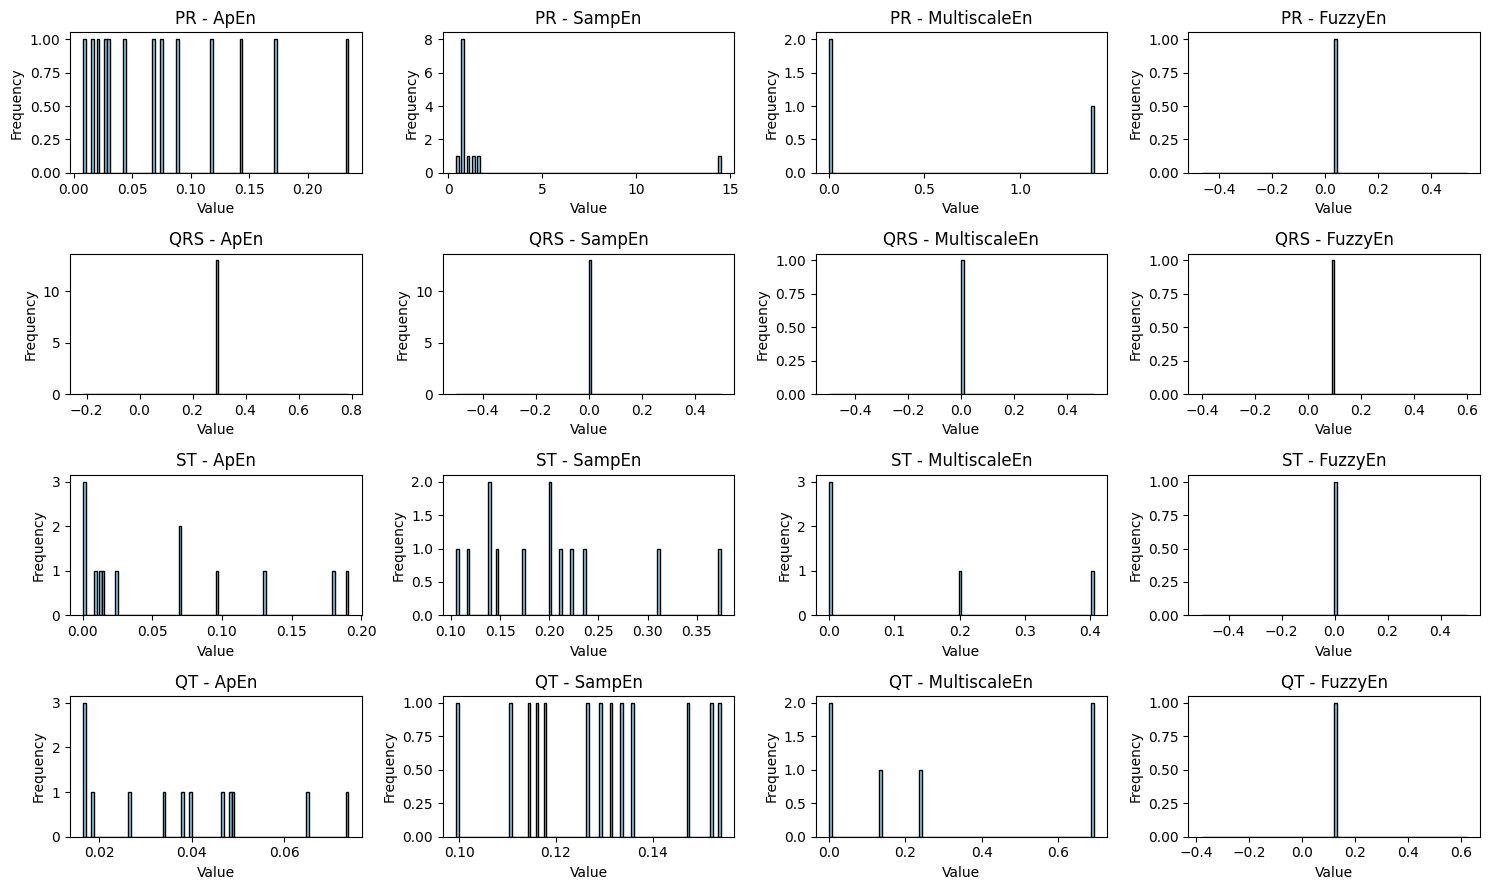

In [67]:
plot_entropy_histograms(entropy_results)

In [68]:
def normalize_0_1_simple(signal):
    signal = np.array(signal)
    return (signal - np.min(signal)) / (np.max(signal) - np.min(signal))

In [75]:
index = 12121
ecg_ = Y_train[index, :, 1]
label = Z_train.loc[index]
print(f"Label for index {index}: {label.to_dict()}")

Label for index 12121: {'NORM': 0, 'MI': 0, 'STTC': 0, 'CD': 1, 'HYP': 0}


Label for index 12121: {'NORM': 0, 'MI': 0, 'STTC': 0, 'CD': 1, 'HYP': 0}


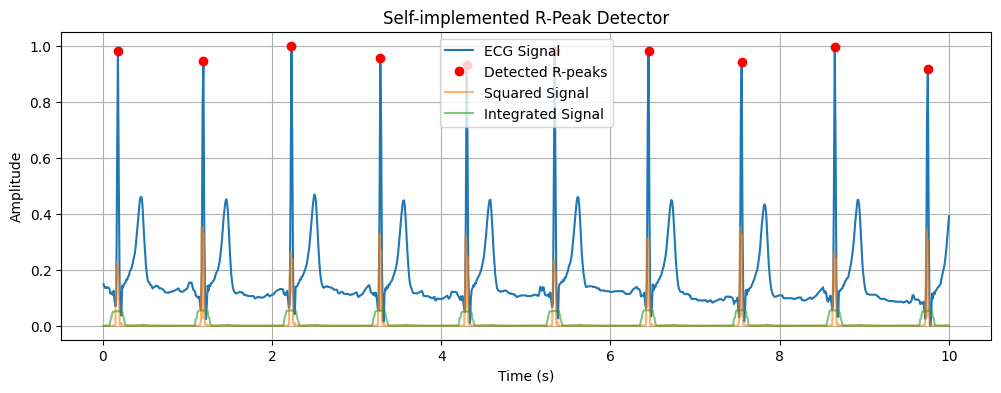

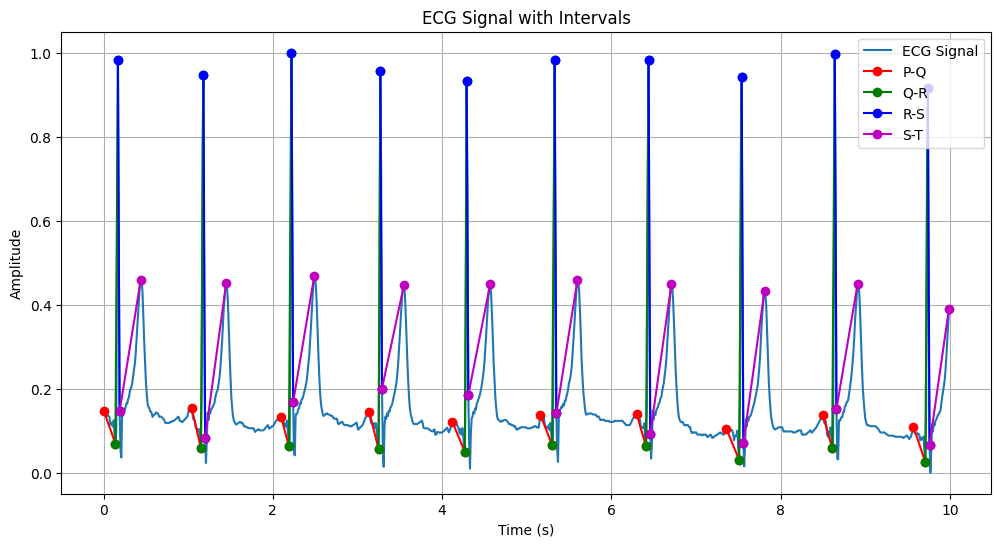

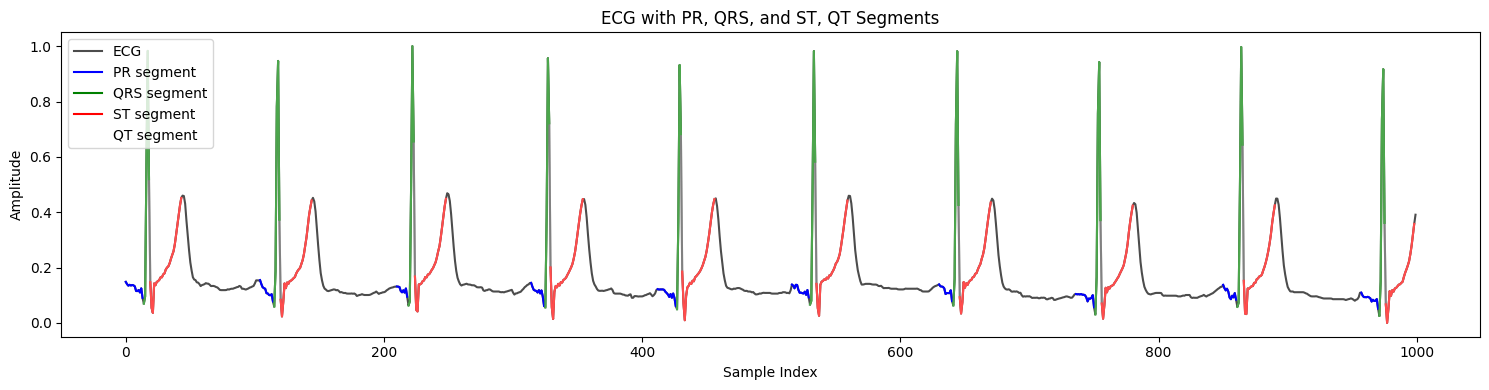

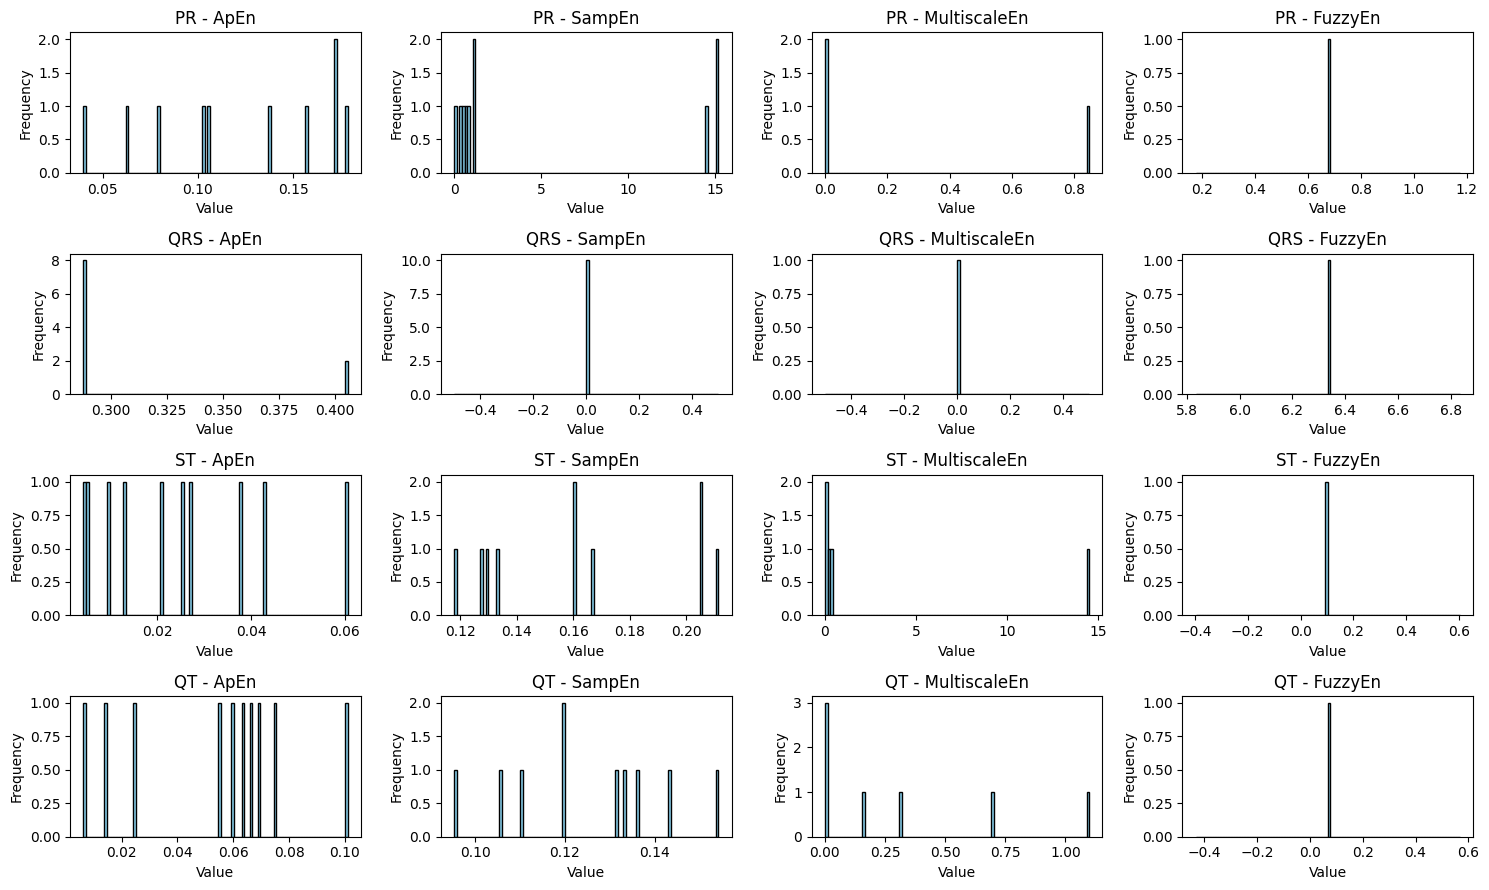


ECG Entropy:
  ApEn: mean=0.1998, std=0.0000
  SampEn: mean=0.1020, std=0.0000
  MultiscaleEn: mean=0.5382, std=0.2304
  FuzzyEn: mean=0.1087, std=0.0000

PR Entropy:
  ApEn: mean=0.1205, std=0.0473
  SampEn: mean=4.9484, std=6.5711
  MultiscaleEn: mean=0.2824, std=0.3994
  FuzzyEn: mean=0.6750, std=0.0000

QRS Entropy:
  ApEn: mean=0.3112, std=0.0471
  SampEn: mean=0.0000, std=0.0000
  MultiscaleEn: mean=0.0000, std=0.0000
  FuzzyEn: mean=6.3338, std=0.0000

ST Entropy:
  ApEn: mean=0.0246, std=0.0173
  SampEn: mean=0.1617, std=0.0334
  MultiscaleEn: mean=3.0251, std=5.7438
  FuzzyEn: mean=0.1030, std=0.0000

QT Entropy:
  ApEn: mean=0.0535, std=0.0280
  SampEn: mean=0.1249, std=0.0172
  MultiscaleEn: mean=0.3235, std=0.3928
  FuzzyEn: mean=0.0682, std=0.0000


,PR_ApEn,PR_SampEn,PR_FuzzyEn,QRS_ApEn,QRS_SampEn,QRS_FuzzyEn,ST_ApEn,ST_SampEn,ST_FuzzyEn,QT_ApEn,QT_SampEn,QT_FuzzyEn
0,0.079072,0.693147,0.675029,0.287682,-0.0,6.333762,0.027169,0.160343,0.103009,0.006250,0.095310,0.068202
1,0.171898,15.201805,NaN,0.287682,-0.0,NaN,0.043062,0.204794,NaN,0.063572,0.105361,NaN
2,0.039755,14.508658,NaN,0.287682,-0.0,NaN,0.025437,0.167054,NaN,0.066108,0.133531,NaN
3,0.156495,1.098612,NaN,0.405465,-0.0,NaN,0.012754,0.133531,NaN,0.014769,0.110348,NaN
4,0.137377,0.485508,NaN,0.405465,-0.0,NaN,0.037637,0.204794,NaN,0.055122,0.136132,NaN
5,0.102217,1.098612,NaN,0.287682,-0.0,NaN,0.009467,0.129212,NaN,0.024512,0.131336,NaN
6,0.171898,15.201805,NaN,0.287682,-0.0,NaN,0.005384,0.127833,NaN,0.059678,0.119801,NaN
7,0.062710,0.348307,NaN,0.287682,-0.0,NaN,0.004267,0.117783,NaN,0.100938,0.143101,NaN
8,0.105361,-0.000000,NaN,0.287682,-0.0,NaN,0.020757,0.160343,NaN,0.069623,0.119801,NaN
9,0.178494,0.847298,NaN,0.287682,-0.0,NaN,0.060560,0.211309,NaN,0.074616,0.154151,NaN


In [76]:
index = 12121
ecg_ = Y_train[index, :, 1]
label = Z_train.loc[index]
print(f"Label for index {index}: {label.to_dict()}")
ecg_ = normalize_0_1_simple(ecg_)
fs = 100
r_peaks, integrated, squared, _ = detect_r_peaks(ecg_, fs)
t = np.arange(1, len(ecg_) + 1) / fs
plot_r_peak_detection(t, ecg_, r_peaks, squared, integrated)
intervals = compute_intervals(ecg_, r_peaks, fs)
segments = extract_intervals_segments(ecg_, intervals)
plot_intervals(ecg_, intervals, fs)
plot_extracted_segments(ecg_, segments)
entropy_results = compute_entropy_for_segments(ecg_, segments, m = 2)
plot_entropy_histograms(entropy_results)
display_entropy_tables(entropy_results)